## Customer Churn Prediction Using Machine Learning

## References

- Dataset: *https://drive.google.com/file/d/1zKOLtO2e3lW788lTT9OE527OMHoxU4pN/view?usp=sharing*
- PPT: *https://docs.google.com/presentation/d/1b2_H-HoJlZ_ScoWqkDFTpWsrmTOuv23l/edit?usp=sharing&ouid=109111249306542709421&rtpof=true&sd=true*
- Recording: *https://youtu.be/XiF2rsGtzHc*
- [XGBoost Documentation](https://xgboost.readthedocs.io/)
- [Scikit-learn Documentation](https://scikit-learn.org/stable/documentation.html)

## Problem Definition

In the competitive landscape of customer-centric businesses, retaining existing customers is crucial. Churn prediction helps businesses identify customers who are likely to discontinue their services. The goal of this project is to build predictive models to accurately predict customer churn, understand the key factors influencing churn, and provide actionable insights to improve customer retention strategies.


## Importing Libraries

We begin by importing the necessary Python libraries for data manipulation, visualization, and modeling.


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading and Overview

### 4.1 Data Loading

We load the dataset into a pandas DataFrame for analysis.


In [7]:
data = pd.read_csv("C:/Users/patron/Downloads/customer_training.csv")

### 4.2 Initial Data Exploration

Let's explore the first few rows of the dataset and check for missing values.


In [9]:
data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [10]:
data.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

### 4.3 Handling Missing Values

We notice that there are missing values in the dataset. We'll handle them appropriately.


In [12]:
data.dropna(inplace=True)

In [13]:
print(data.isnull().sum())


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [14]:
data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## Exploratory Data Analysis (EDA)

We perform EDA to understand the data distributions and relationships between variables.


### 5.1 Target Variable Distribution

We analyze the distribution of the target variable, `Churn`.


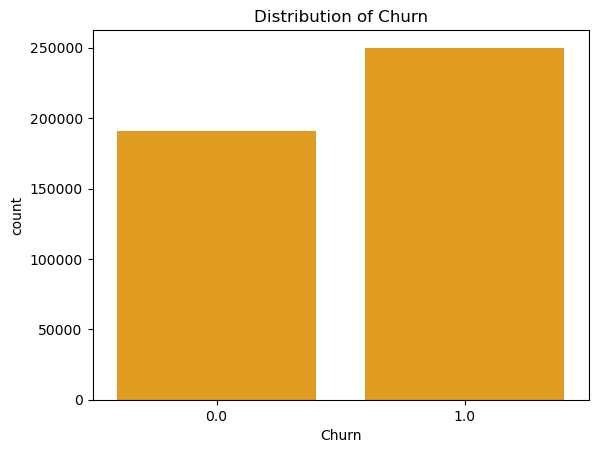

Churn Rate:
 Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64


In [17]:
sns.countplot(data=data, x='Churn', color='orange')
plt.title('Distribution of Churn')
plt.show()

churn_rate = data['Churn'].value_counts(normalize=True)
print("Churn Rate:\n", churn_rate)


### 5.2 Numerical Feature Analysis

We examine the distributions of numerical features and their relationships with `Churn`.


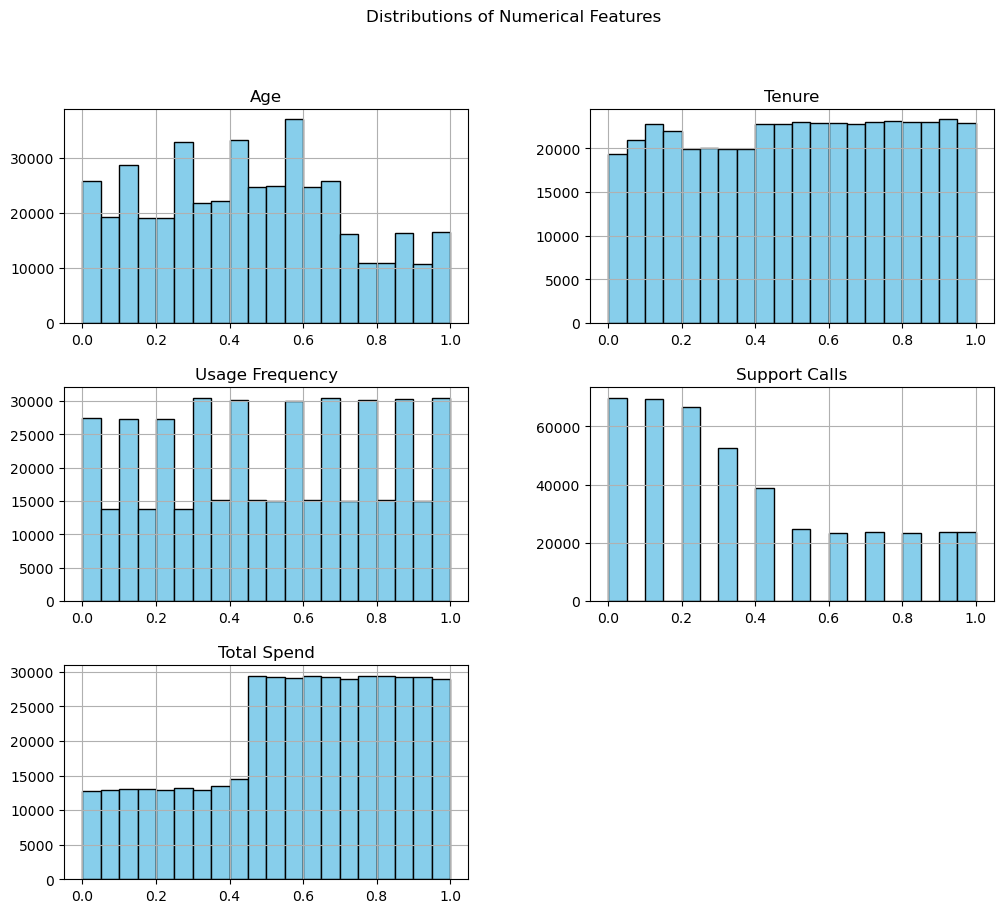

In [110]:
numerical_features = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Total Spend']

data[numerical_features].hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distributions of Numerical Features')
plt.show()


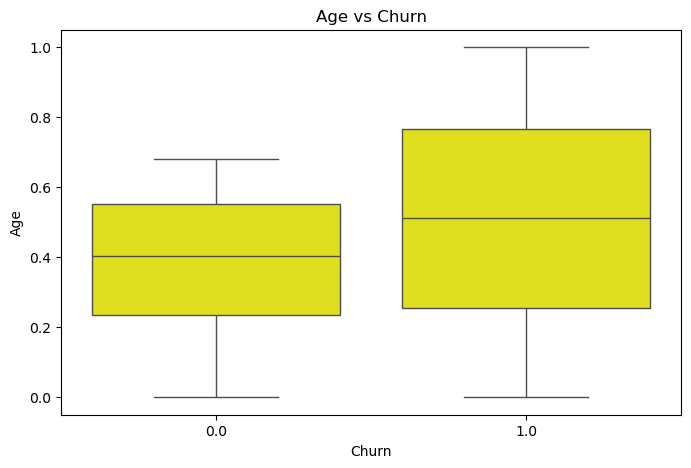

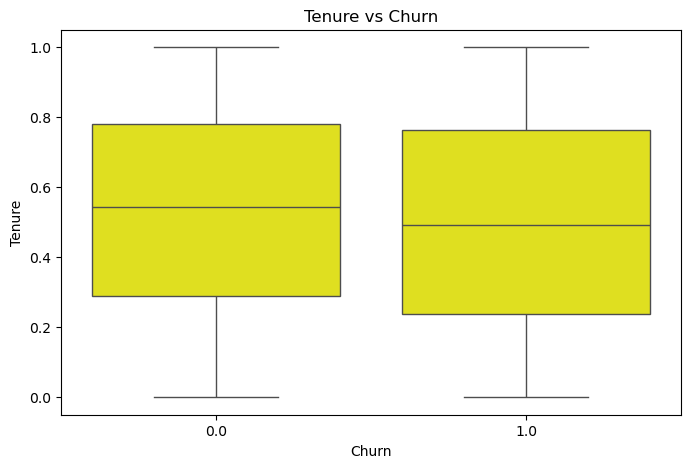

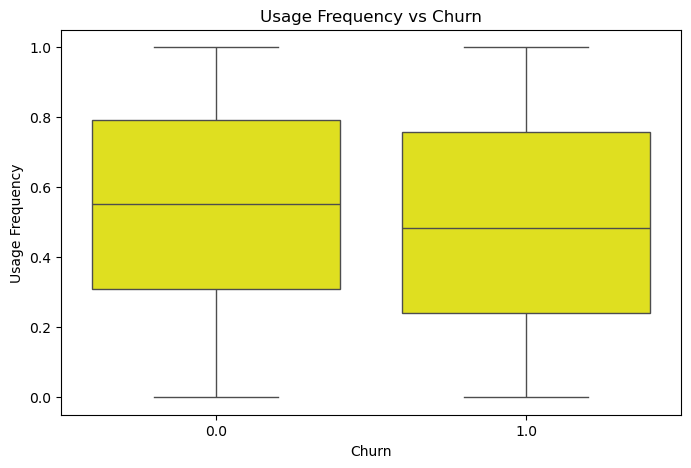

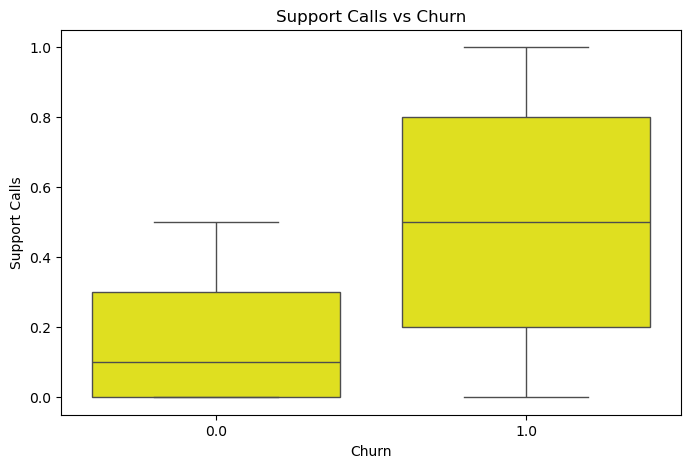

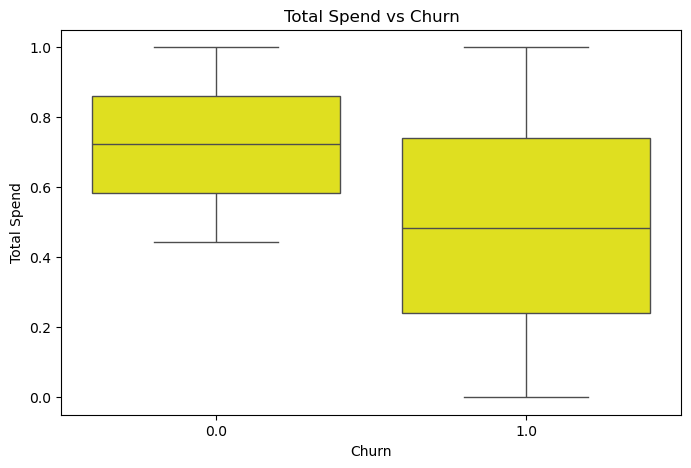

In [116]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data, x='Churn', y=feature, color = 'yellow')
    plt.title(f'{feature} vs Churn')
    plt.show()


### 5.3 Categorical Feature Analysis

We explore the relationship between categorical features and `Churn`.


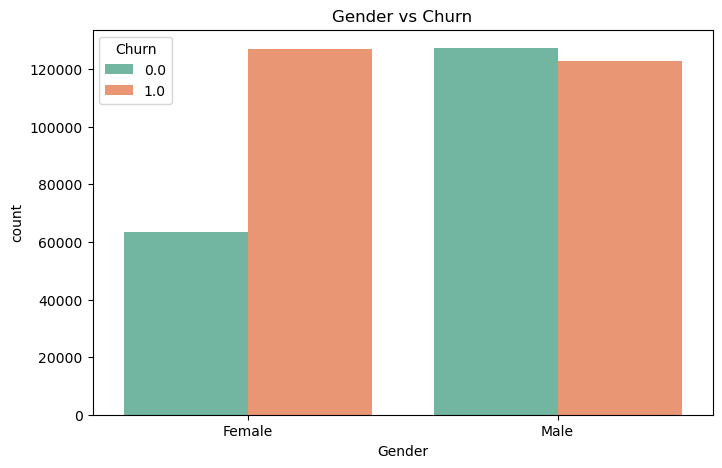

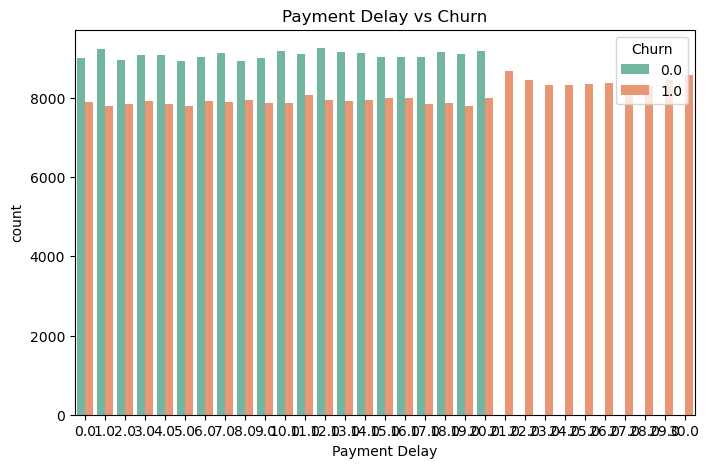

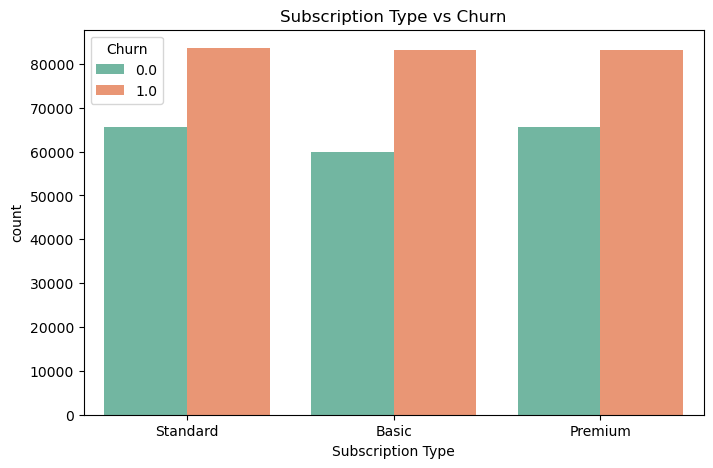

In [22]:
categorical_features = ['Gender', 'Payment Delay', 'Subscription Type']

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data, x=feature, hue='Churn', palette='Set2')
    plt.title(f'{feature} vs Churn')
    plt.show()


### 5.4 Correlation Analysis

We compute the correlation matrix to identify relationships between numerical features and `Churn`.


Correlation of Numerical Features with Churn:
Churn               1.000000
Support Calls       0.574267
Payment Delay       0.312129
Age                 0.218394
Last Interaction    0.149616
Usage Frequency    -0.046101
Tenure             -0.051919
Total Spend        -0.429355
CustomerID         -0.839365
Name: Churn, dtype: float64


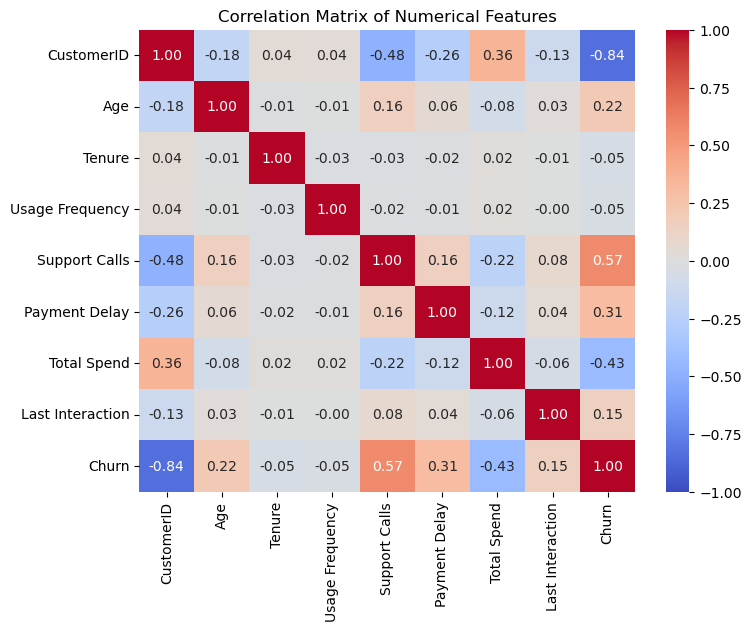

In [24]:
correlation_matrix = data.select_dtypes(include=['number']).corr()
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)

print("Correlation of Numerical Features with Churn:")
print(churn_correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


## Feature Engineering

We create new features and transform existing ones to improve model performance.


### 6.1 Creating New Features

We engineer new features that may be predictive of churn.


In [27]:
data['Loyalty Index'] = data['Tenure'] * data['Total Spend']
data['High Support Calls'] = (data['Support Calls'] > 5).astype(int)
data['Payment Risk'] = (data['Payment Delay'] > 10).astype(int)


### 6.2 Encoding Categorical Variables

We convert categorical variables into numerical format using encoding techniques.


In [29]:
data['Gender'] = data['Gender'].map({'Female': 0, 'Male': 1})

data = pd.get_dummies(data, columns=['Subscription Type', 'Contract Length'], drop_first=True)

print(data.head())


   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0       0    39.0             14.0            5.0   
1         3.0  65.0       0    49.0              1.0           10.0   
2         4.0  55.0       0    14.0              4.0            6.0   
3         5.0  58.0       1    38.0             21.0            7.0   
4         6.0  23.0       1    32.0             20.0            5.0   

   Payment Delay  Total Spend  Last Interaction  Churn  Loyalty Index  \
0           18.0        932.0              17.0    1.0        36348.0   
1            8.0        557.0               6.0    1.0        27293.0   
2           18.0        185.0               3.0    1.0         2590.0   
3            7.0        396.0              29.0    1.0        15048.0   
4            8.0        617.0              20.0    1.0        19744.0   

   High Support Calls  Payment Risk  Subscription Type_Premium  \
0                   0             1                      False   
1 

### 6.3 Feature Scaling

We scale numerical features to bring them onto a similar scale.


In [31]:
from sklearn.preprocessing import MinMaxScaler

numerical_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Total Spend', 'Loyalty Index']

scaler = MinMaxScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

print(data[numerical_cols].head())


        Age    Tenure  Usage Frequency  Support Calls  Total Spend  \
0  0.255319  0.644068         0.448276            0.5     0.924444   
1  1.000000  0.813559         0.000000            1.0     0.507778   
2  0.787234  0.220339         0.103448            0.6     0.094444   
3  0.851064  0.627119         0.689655            0.7     0.328889   
4  0.106383  0.525424         0.655172            0.5     0.574444   

   Loyalty Index  
0       0.605142  
1       0.453973  
2       0.041569  
3       0.249549  
4       0.327947  


## Model Development

We develop predictive models to predict customer churn.


### 7.1 Train-Test Split

We split the data into training and testing sets.


In [34]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['CustomerID', 'Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (352665, 15)
Testing data shape: (88167, 15)


### 7.2 Logistic Regression

We train a Logistic Regression model and evaluate its performance.


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC


In [37]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


Confusion Matrix:
[[35578  2589]
 [ 5480 44520]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90     38167
         1.0       0.95      0.89      0.92     50000

    accuracy                           0.91     88167
   macro avg       0.91      0.91      0.91     88167
weighted avg       0.91      0.91      0.91     88167


ROC-AUC Score: 0.9652


### 7.3 Random Forest Classifier

We train a Random Forest model and evaluate its performance.


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC


In [40]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"\nROC-AUC Score: {roc_auc_rf:.4f}")


Confusion Matrix:
[[38164     3]
 [   71 49929]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167


ROC-AUC Score: 1.0000


### 7.4 XGBoost Classifier

We train an XGBoost model and evaluate its performance.


In [102]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC


In [44]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"\nROC-AUC Score: {roc_auc_xgb:.4f}")


Confusion Matrix:
[[38167     0]
 [   43 49957]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167


ROC-AUC Score: 1.0000


## Model Evaluation and Comparison

We compare the performance of different models using various evaluation metrics.


### 8.1 ROC Curves

We plot ROC curves to visualize the performance of models across different thresholds.


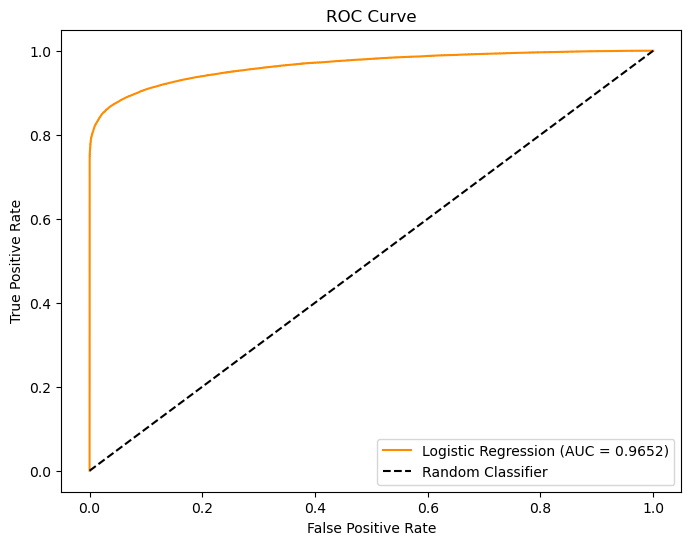

In [47]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


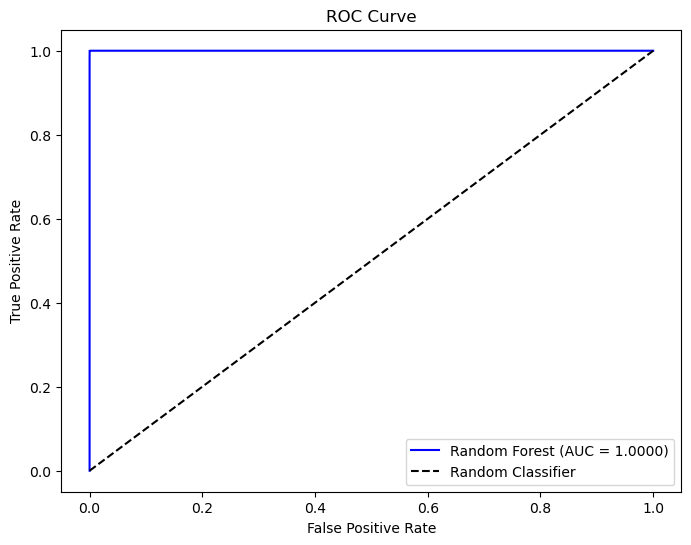

In [48]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


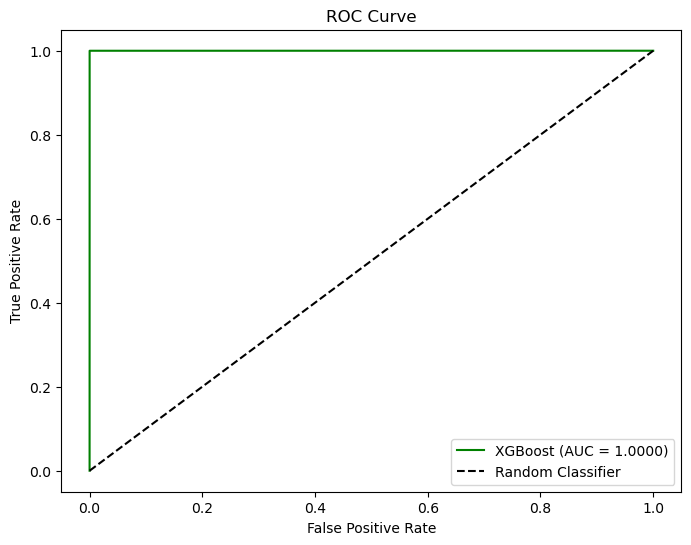

In [49]:
from sklearn.metrics import roc_curve

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


### 8.3 Feature Importance

We analyze the importance of features as determined by the models.


                    Feature  Importance
4             Support Calls    0.201613
6               Total Spend    0.185782
0                       Age    0.135647
13  Contract Length_Monthly    0.124665
5             Payment Delay    0.119258
9        High Support Calls    0.115597
7          Last Interaction    0.033942
1                    Gender    0.029280
8             Loyalty Index    0.022917
2                    Tenure    0.014649


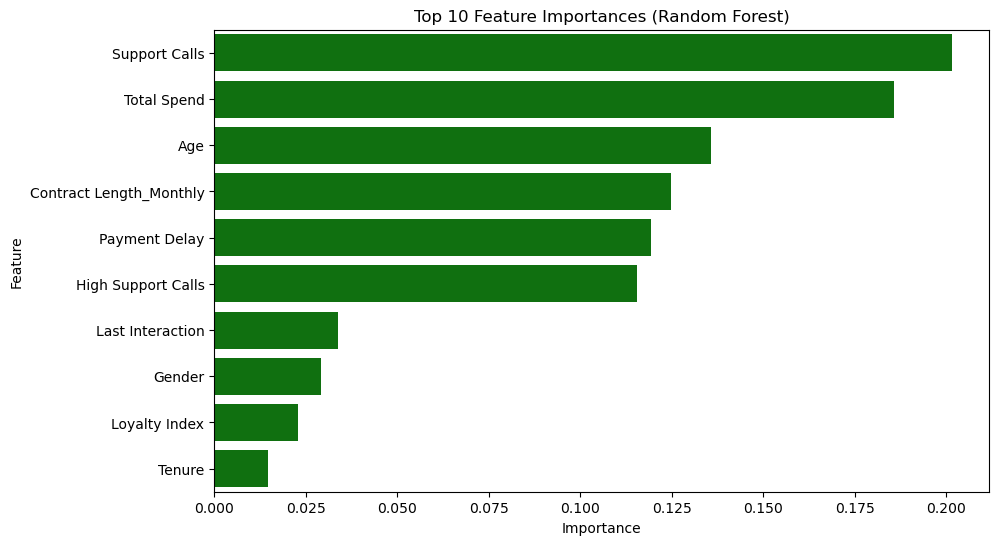

In [51]:
# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), color='green')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()


                       Feature  Importance
6                  Total Spend    0.262771
13     Contract Length_Monthly    0.210625
4                Support Calls    0.208327
5                Payment Delay    0.122460
7             Last Interaction    0.071713
0                          Age    0.048683
12  Subscription Type_Standard    0.033680
1                       Gender    0.020748
2                       Tenure    0.010029
3              Usage Frequency    0.006165


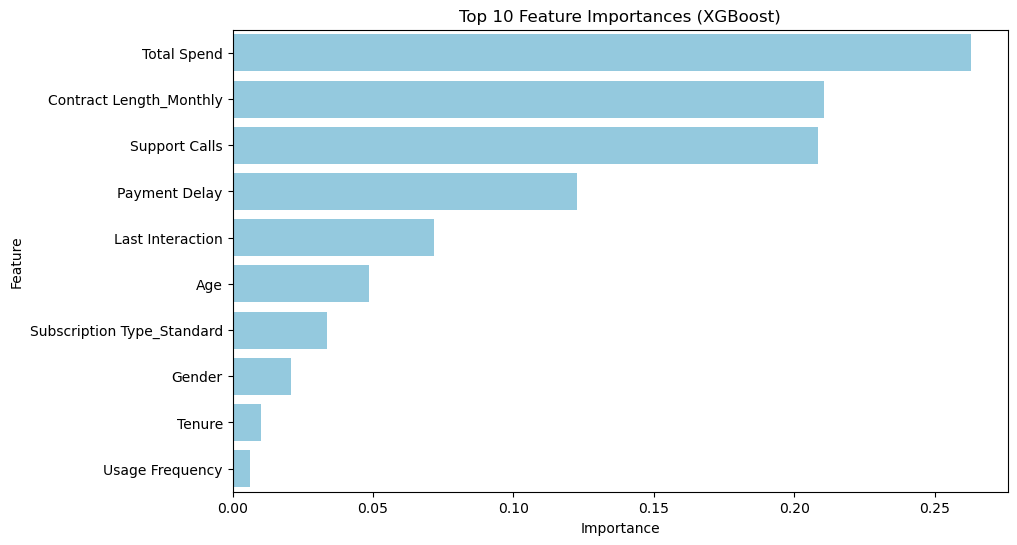

In [52]:
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(xgb_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance.head(10), color='skyblue')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.show()



### 8.4 Model Comparison Summary

We compare the models based on their evaluation metrics.

| Model                | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|----------------------|----------|-----------|--------|----------|---------|
| Logistic Regression  | 91%      | 0.95      | 0.89   | 0.92     | 0.9652  |
| Random Forest        | 100%     | 1.00      | 1.00   | 1.00     | 1.0000  |
| XGBoost              | 100%     | 1.00      | 1.00   | 1.00     | 1.0000  |

*Logistic Regression shows strong performance with an ROC-AUC of 0.9652, but Random Forest and XGBoost models achieve perfect scores. Further evaluation on overfitting and generalizability might be necessary for Random Forest and XGBoost.*



### 8.5 Baseline Model: Dummy Classifier

To evaluate the performance of our predictive models, we compare them with a baseline model. The Dummy Classifier predicts the majority class and serves as a benchmark for our model's performance.


In [55]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy_clf = DummyClassifier(strategy="most_frequent")  # Always predicts the majority class
dummy_clf.fit(X_train, y_train)

dummy_pred = dummy_clf.predict(X_test)
dummy_report = classification_report(y_test, dummy_pred, zero_division=0)

print("Dummy Model Classification Report:")
print(dummy_report)


Dummy Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     38167
         1.0       0.57      1.00      0.72     50000

    accuracy                           0.57     88167
   macro avg       0.28      0.50      0.36     88167
weighted avg       0.32      0.57      0.41     88167



## Hyperparameter Tuning

We perform hyperparameter tuning to optimize the XGBoost model.


### 9.1 Grid Search for XGBoost

In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}


In [59]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc', 
    cv=3,  
    verbose=1,
    n_jobs=-1  
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best AUC Score:", grid_search.best_score_)


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best AUC Score: 0.9999997201721986


### 9.2 Best Model Evaluation

We evaluate the XGBoost model with the best parameters found.


In [61]:
best_xgb = XGBClassifier(
    learning_rate=0.2,
    max_depth=7,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

best_xgb.fit(X_train, y_train)

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

roc_auc_best = roc_auc_score(y_test, y_prob_best)
print("\nROC-AUC Score:", roc_auc_best)


Confusion Matrix:
[[38167     0]
 [    7 49993]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167


ROC-AUC Score: 0.999999726989284


## Error Analysis

We analyze the errors made by the best model to understand its limitations.


## 10.1 Analyzing Misclassifications

In [64]:
false_positives = np.where((y_test == 0) & (y_pred_best == 1))[0]
false_negatives = np.where((y_test == 1) & (y_pred_best == 0))[0]

print("Number of False Positives:", len(false_positives))
print("Number of False Negatives:", len(false_negatives))


Number of False Positives: 0
Number of False Negatives: 7


## 10.2 Prediction Probability Distribution

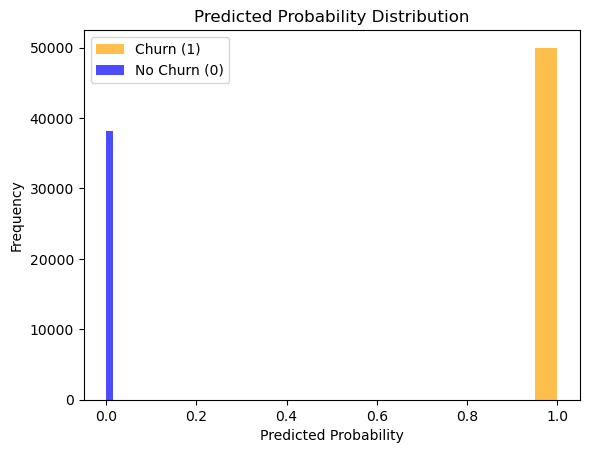

In [66]:
plt.hist(y_prob_best[y_test == 1], bins=20, alpha=0.7, label='Churn (1)', color='orange')
plt.hist(y_prob_best[y_test == 0], bins=20, alpha=0.7, label='No Churn (0)', color='blue')
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()


## Conclusion

In this project, we developed several machine learning models to predict customer churn. The XGBoost classifier, especially after hyperparameter tuning, outperformed other models with an exceptional ROC-AUC score. Key features influencing churn included `Total Spend`, `Support Calls`, and `Payment Delay`.

By accurately predicting churn, businesses can proactively engage at-risk customers with targeted retention strategies, potentially reducing churn rates and increasing customer lifetime value.

**Future Work:**

- **Model Deployment:** Integrate the model into a production environment.
- **Cost-Benefit Analysis:** Assess the financial implications of retention strategies based on model predictions.
- **Additional Features:** Incorporate more data sources to enrich the model.

